# 02_datacheck.ipynb 概要

このファイルは「01_src_sql/00_CsvCreate.sql（実データ）」または「03_notebooks/01_generate_dummy.ipynb」にて生成した"data/01out_individual_raw.csv"を可視化する。

※新たなフィールド生成は特に行わない。ダミーについては age_group 年齢区分を01 で生成済みだが、実データのみ区分生成を追加で処理する。

## import 
data/01out_individual_raw.csv

## output
04_datacheck/
- fig0_taxable_ratio_by_year.png
- fig1_income_salary_gross_hist.png
- fig1_income_pension_gross_hist.png
- fig1_tax_amount_hist.png
- fig2_income_salary_gross_log_hist.png
- fig2_income_pension_gross_log_hist.png
- fig2_tax_amount_log_hist.png
- fig3_income_salary_gross_年齢区分×性別_boxplot.png
- fig3_income_pension_gross_年齢区分×性別_boxplot.png
- fig3_tax_amount_年齢区分×性別_boxplot.png
- fig4_income_salary_gross_年齢区分×性別_barplot.png
- fig4_income_pension_gross_年齢区分×性別_barplot.png
- fig4_tax_amount_年齢区分×性別_barplot.png
- fig5_heatmap.png
- fig5_heatmap_Top10andBottom10.png
- fig6_scatter_income_salary_grossandtax_amount.png
- fig6_scatter_income_pension_grossandtax_amount.png
- fig7_scatter_income_salary_grossanddeduct_tax_furusato.png
- fig7_scatter_income_salary_grossanddeduct_tax_housing.png
- fig7_scatter_taxable_incomeanddeduct_tax_furusato.png
- fig7_scatter_taxable_incomeanddeduct_tax_housing.png
- fig8_1_teigaku_show.png
- fig8_2_teigaku_age_gender_show.png
- fig8_3_teigaku_yearsort_show.png
- fig9_給与収入vs給与所得_barplot.png


---

# ディレクトリ設定
03_notebooks/ から実行してもプロジェクトルート基準の相対パス（data/, tax_reform, 04_datacheck/）が解決できるよう、カレントディレクトリをルートへ戻す

output フォルダをSAVE_DIRで指定

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "03_notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "00_src_settings"))
    
SAVE_DIR = "04_datacheck"

---

# ライブラリインポート

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from tax_reform import compute_income_tax_rate

print("Python version:", sys.version)

Python version: 3.14.4 (main, Apr 14 2026, 14:30:57) [MSC v.1944 64 bit (AMD64)]


---


# データ読み込み

In [3]:
df = pd.read_csv("data/01out_individual_raw.csv", encoding="utf-8-sig")
df.head()
print(df.columns)
print(df.dtypes)
print(f"読込完了: {len(df):,} 件 / {df['year'].nunique()} 年分")

print(df['gender'].unique(), df['age_group'].unique())

Index(['person_id', 'year', 'gender', 'age', 'age_group',
       'income_salary_gross', 'income_pension_gross', 'income_salary',
       'income_business', 'income_farming', 'income_property',
       'income_interest', 'income_dividend', 'income_pension',
       'income_misc_business', 'income_other', 'income_stcg', 'income_ltcg',
       'income_occasional', 'sep_stcg_general', 'sep_stcg_reduced',
       'sep_ltcg_general', 'sep_ltcg_specific', 'sep_ltcg_reduced',
       'sep_stock_general', 'sep_stock_listed', 'sep_dividend_listed',
       'sep_futures', 'sep_forestry', 'deduct_social_ins',
       'deduct_small_biz_ins', 'deduct_life_ins', 'deduct_earthquake_ins',
       'deduct_casualty', 'deduct_medical', 'deduct_disability',
       'deduct_widow', 'deduct_spouse', 'deduct_spouse_special',
       'deduct_dependent', 'deduct_basic', 'deduct_working_student',
       'deduct_donation_income', 'n_dependent', 'taxable_income',
       'deduct_tax_housing', 'deduct_tax_furusato', 'taxcredit

---

# fig0 : 課税・非課税割合（2026-09-09追加）
非課税（tax_amount=0）と課税（tax_amount!=0）の人数を年度別に比較する

In [ ]:
# --- fig0 : 課税・非課税割合（年度別） 2026-09-09追加 -------------------------------------
def plot_taxable_ratio_by_year(df, show: bool = False):
    """
    tax_amount が 0円（非課税）か非0円（課税）かの人数を年度別に棒グラフで比較する。
    """
    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[df["year"] == year]
        counts = [
            (df_year["tax_amount"] == 0).sum(),
            (df_year["tax_amount"] != 0).sum(),
        ]
        axes[i].bar(["非課税", "課税"], counts)
        axes[i].set_title(f"{year}年度")
        axes[i].set_ylabel("人数")
        for j, c in enumerate(counts):
            axes[i].text(j, c, f"{c:,}", ha="center", va="bottom")

    fig.suptitle("課税・非課税 人数比較")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, "fig0_taxable_ratio_by_year.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

In [ ]:
plot_taxable_ratio_by_year(df, show=True)

---


# fig1 : histgram 
給与収入、年金収入、税額の分布

In [4]:
# --- fig1 : histgram -------------------------------------------------------------------
def plot_hist_by_year(df, col, show: bool = False): # , xticks, xlabels
    """
    col     : 列名（例："税額"）
    xticks  : 目盛りの値リスト
    xlabels : 目盛りのラベルリスト"1000万"]）
    """
    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["year"] == year) & (df[col] > 0)]
        axes[i].hist(df_year[col], bins=50)
        axes[i].set_title(f"{year}年度")
        axes[i].set_xlabel(f"{col}")
        axes[i].set_ylabel("人数")


    fig.suptitle(f"{col} ヒストグラム")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig1_{col}_hist.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig1_income_salary_gross_hist.png


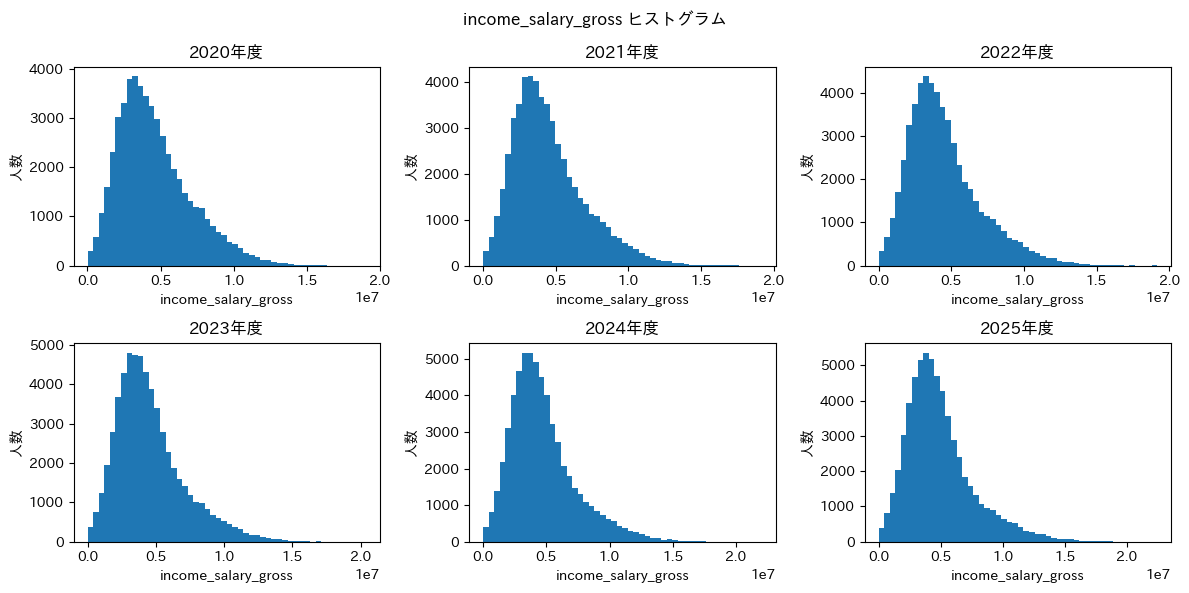

  → 04_datacheck\fig1_income_pension_gross_hist.png


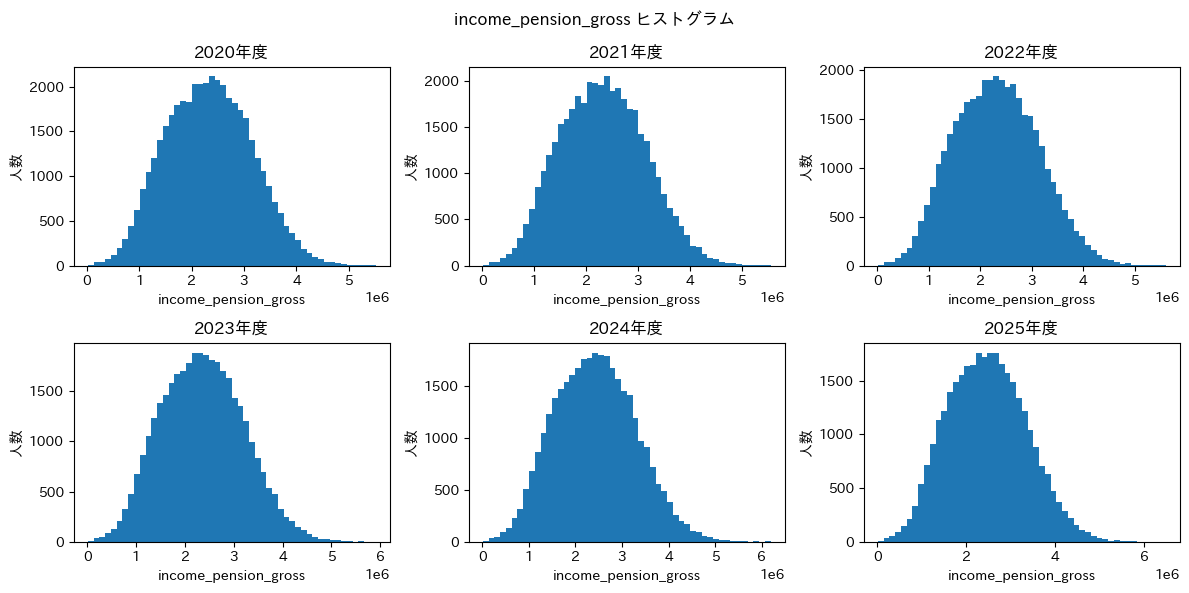

  → 04_datacheck\fig1_tax_amount_hist.png


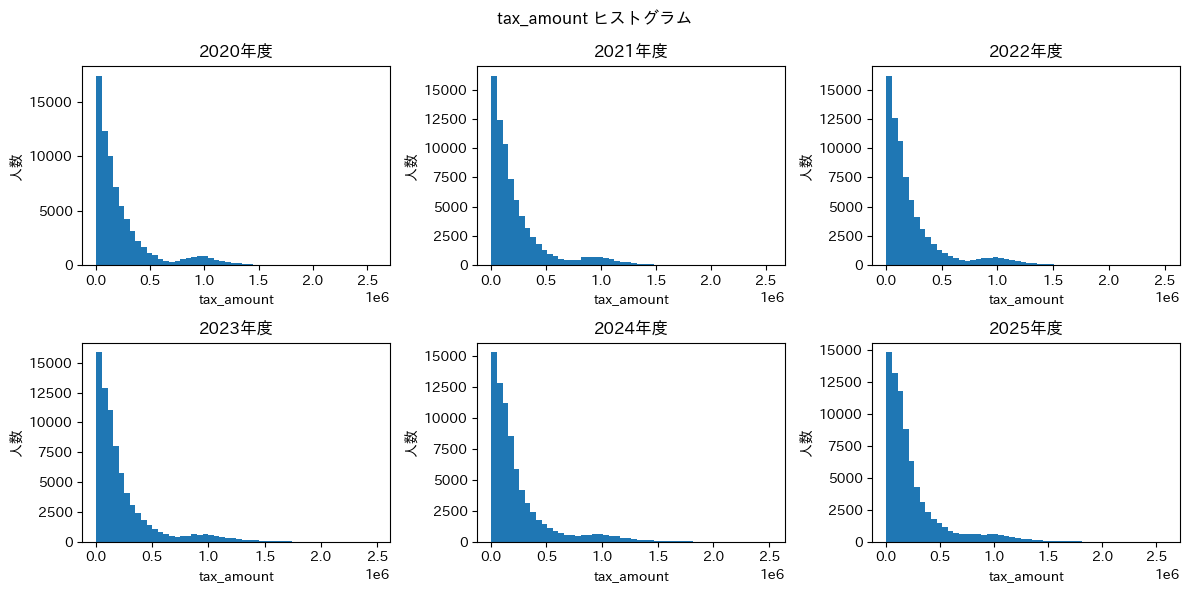

In [5]:
plot_hist_by_year(df, "income_salary_gross", show=True)
plot_hist_by_year(df, "income_pension_gross", show=True)
plot_hist_by_year(df, "tax_amount", show=True)

---


# fig1 : histgram log　
対数変換後の給与収入、年金収入、税額の分布

In [6]:
# --- fig2 : histgram log
def plot_log_hist_by_year(df, col, xticks, xlabels, show: bool = False):
    """
    col     : 列名（例："税額"）
    xticks  : 目盛りの値リスト（例：[3,4,5,6,7]）
    xlabels : 目盛りのラベルリスト（例：["1千","1万","10万","100万","1000万"]）
    """
    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["year"] == year) & (df[col] > 0)]
        axes[i].hist(np.log10(df_year[col]), bins=50)
        axes[i].set_title(f"{year}年度")
        axes[i].set_xlabel(f"{col}（log10スケール）")
        axes[i].set_ylabel("人数")
        axes[i].set_xticks(xticks)
        axes[i].set_xticklabels(xlabels)
    fig.suptitle(f"{col} ヒストグラム(log)")
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig2_{col}_log_hist.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()
    plt.show()

  → 04_datacheck\fig2_income_salary_gross_log_hist.png


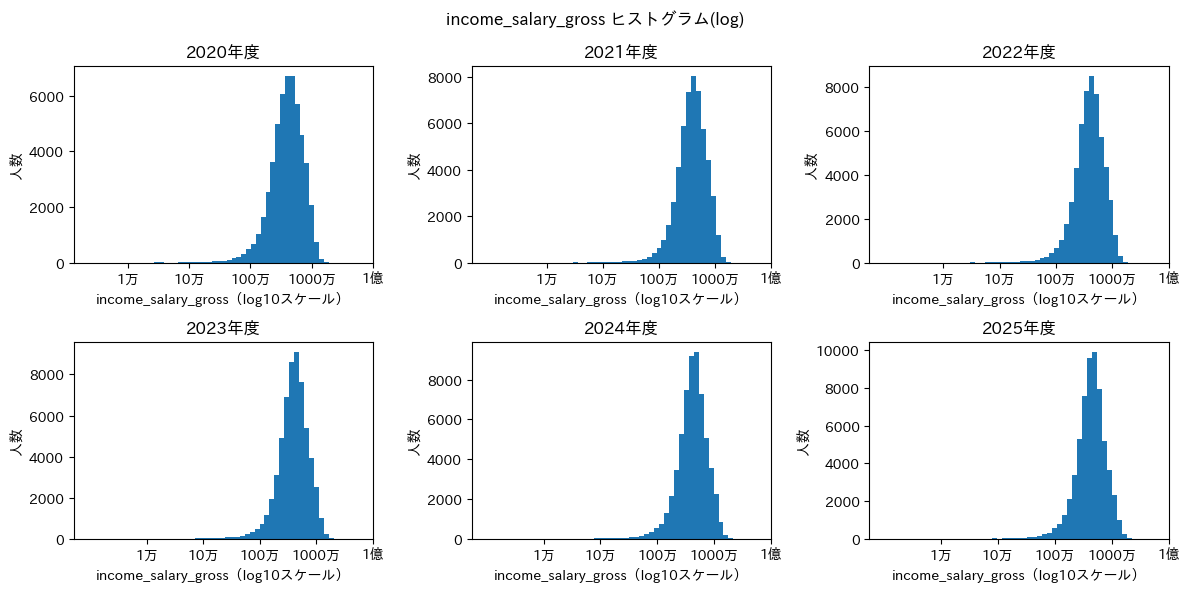

  → 04_datacheck\fig2_income_pension_gross_log_hist.png


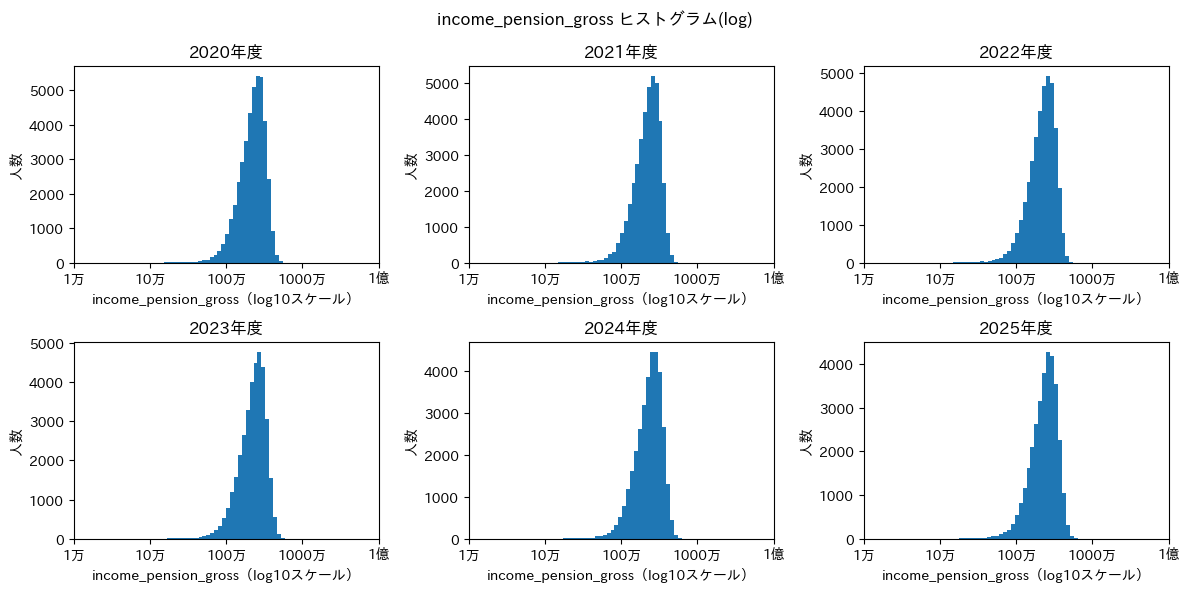

  → 04_datacheck\fig2_tax_amount_log_hist.png


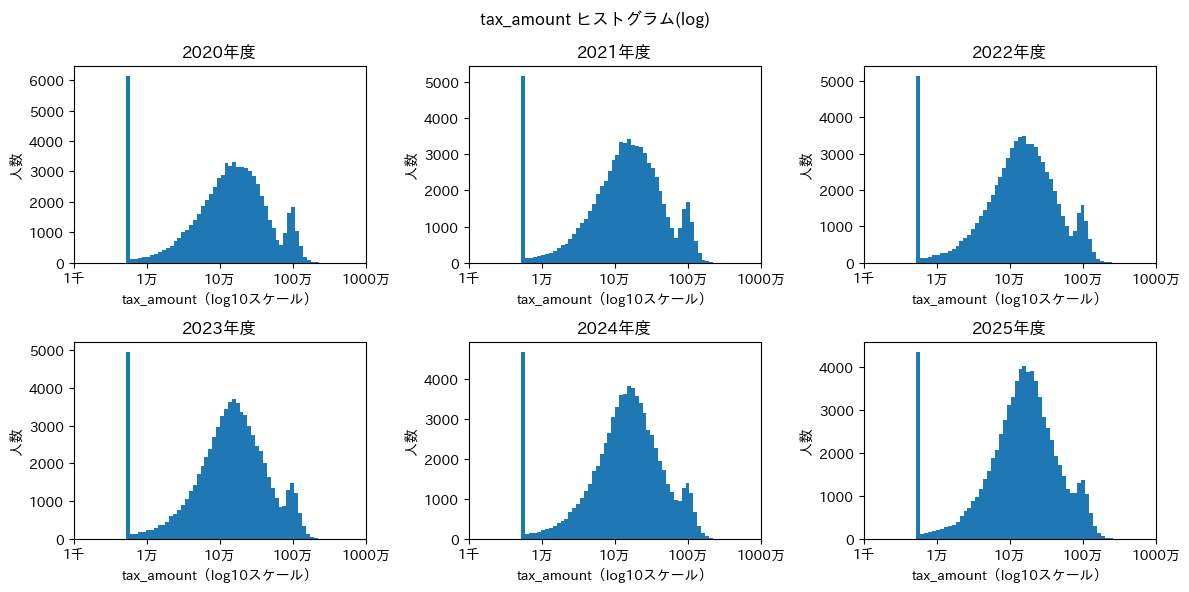

In [7]:
## 給与収入
plot_log_hist_by_year(
    df, "income_salary_gross",
    xticks=[4, 5, 6, 7, 8],
    xlabels=["1万", "10万", "100万", "1000万", "1億"],
    show=True
)
## 年金収入
plot_log_hist_by_year(
    df, "income_pension_gross",
    xticks=[4, 5, 6, 7, 8],
    xlabels=["1万", "10万", "100万", "1000万", "1億"],
    show=True
)
## 税額
plot_log_hist_by_year(
    df, "tax_amount",
    xticks=[3, 4, 5, 6, 7],
    xlabels=["1千", "1万", "10万", "100万", "1000万"],
    show=True
)

---


# fig3 : boxplot （給与、年金、税額）
- 年齢区分ごとの分布
- 性別ごとの分布　　
- 年齢区分×性別ごとの分布

In [8]:
# categorical columns
## 年齢区分の順序を定義(昇順)
def _age_order(df):
    """age_group の昇順リストを返す（"80以上" も正しく最後に来る）"""
    return sorted(
        df["age_group"].unique(),
        key=lambda x: int(x.replace("以上", "").split("-")[0])
    )

# 性別カラー定義（男性=青, 女性=ピンク）。gender列のhue分けで共通利用する
GENDER_COLORS = {0: "#1f77b4", 1: "#e84393"}
GENDER_LABELS = {0: "男性", 1: "女性"}

In [9]:
# --- fig3 : boxplot
def boxplot_by_category(df, value_col, category, show: bool = False):
    """
    value_col : 可視化したい列名（例："給与収入"）
    category  : "age_group" / "gender" / "both" のいずれか
    """

    df_nonzero = df[df[value_col] > 0].copy()

    if category == "age_group":
        plt.figure(figsize=(14, 5))
        sns.boxplot(
            data=df_nonzero,
            x="age_group",
            y=value_col,
            order=_age_order(df_nonzero),
            showfliers=False
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_年齢区分別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()


    elif category == "gender":
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            data=df_nonzero,
            x="gender",
            y=value_col,
            hue="gender",
            palette=GENDER_COLORS,
            legend=False,
            showfliers=False
        )
        plt.title(f"{value_col}　性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_性別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    elif category == "both":
        plt.figure(figsize=(16, 5))
        sns.boxplot(
            data=df_nonzero,
            x="age_group",
            y=value_col,
            order=_age_order(df_nonzero),
            hue="gender",
            palette=GENDER_COLORS,
            showfliers=False
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分×性別")
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles=handles, labels=[GENDER_LABELS[0], GENDER_LABELS[1]], title="性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_年齢区分×性別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    else:
        print("categoryは 'age_group' / 'gender' / 'both' のいずれかを指定してください")

  → 04_datacheck\fig3_income_salary_gross_年齢区分×性別_boxplot.png


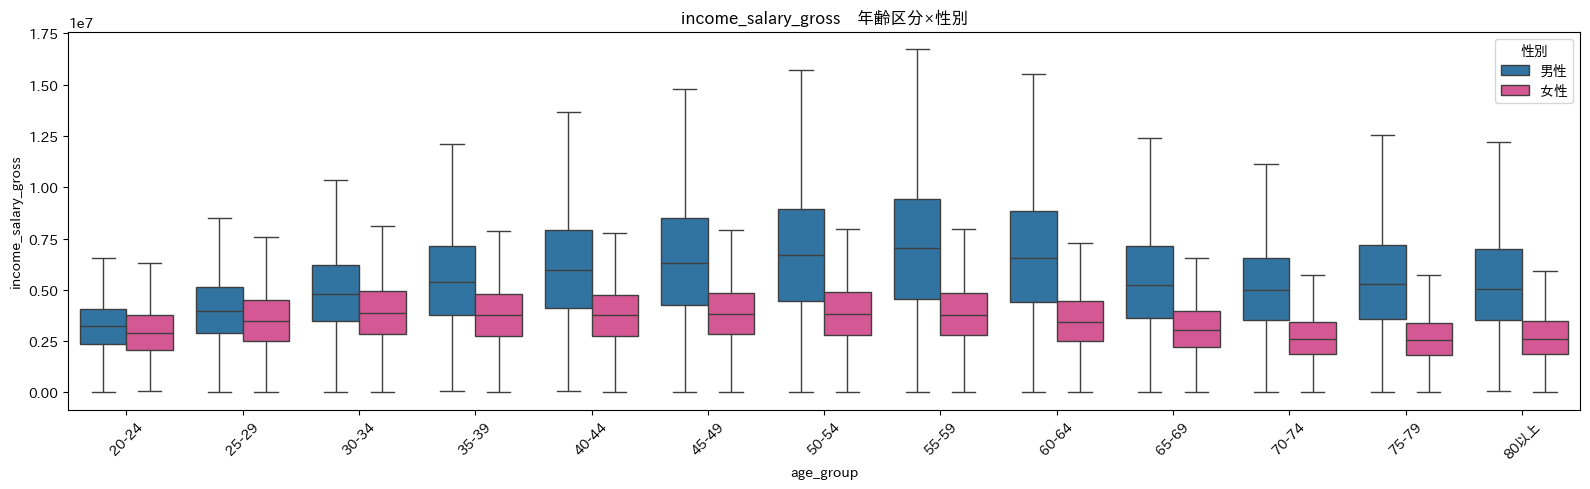

  → 04_datacheck\fig3_income_pension_gross_年齢区分×性別_boxplot.png


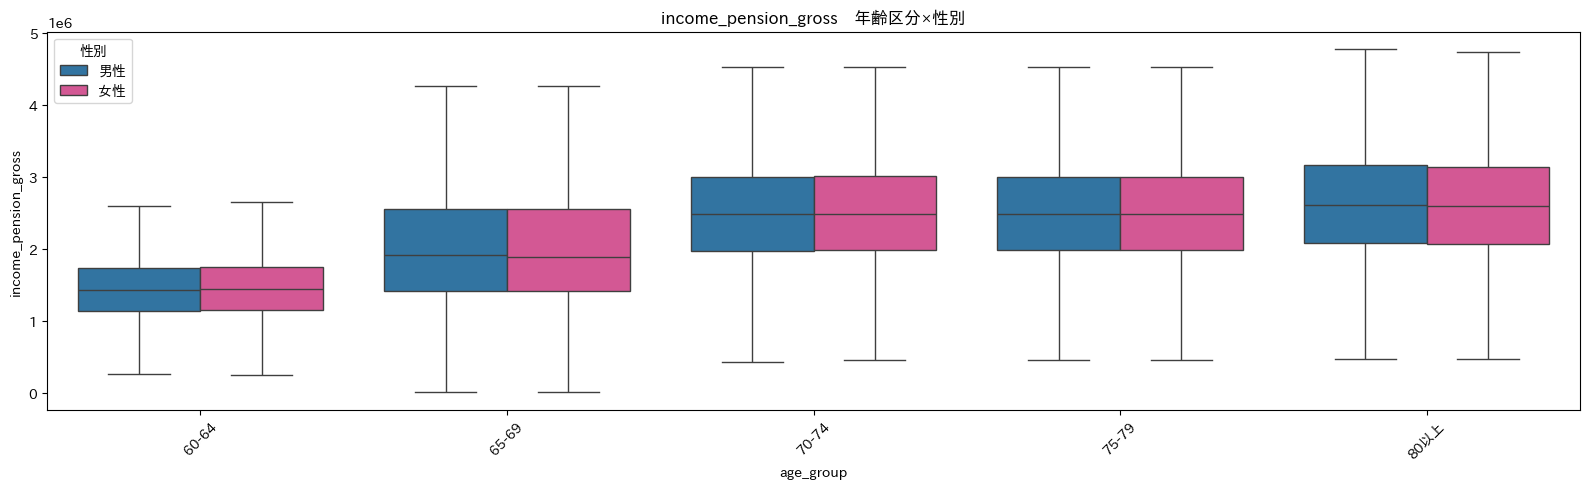

  → 04_datacheck\fig3_tax_amount_年齢区分×性別_boxplot.png


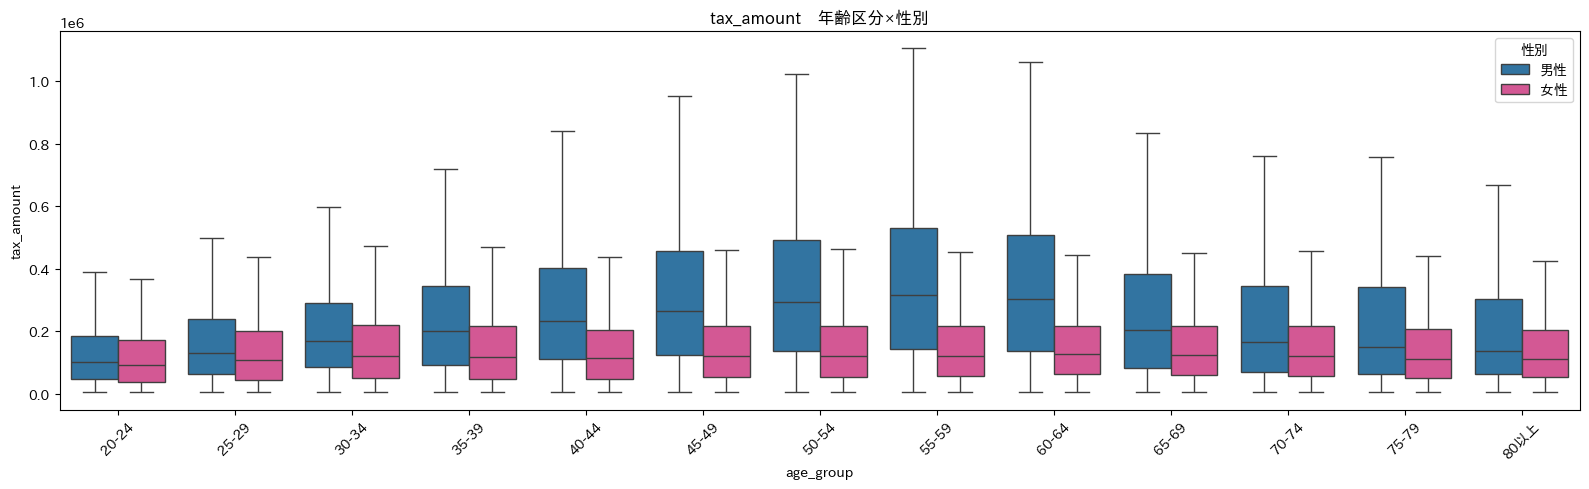

In [10]:
## 給与収入を年齢×性別で区分
boxplot_by_category(df, "income_salary_gross", "both", show=True)
## 年金収入を年齢×性別で区分
boxplot_by_category(df, "income_pension_gross", "both", show=True)
## 税額を年齢×性別で区分
boxplot_by_category(df, "tax_amount", "both", show=True)

---


# fig4 : barplot （給与、年金、税額）
- 年齢区分ごとの分布
- 性別ごとの分布　　
- 年齢区分×性別ごとの分布

In [11]:
# --- fig4 : barplot
def barplot_by_category(df, value_col, category, show: bool = False):
    """
    value_col : 可視化したい列名（例："給与収入"）
    category  : "age_group" / "gender" / "both" のいずれか
    """

    df_nonzero = df[df[value_col] > 0].copy()

    if category == "age_group":
        plt.figure(figsize=(14, 5))
        sns.barplot(
            data=df_nonzero,
            x="age_group",
            y=value_col,
            order=_age_order(df_nonzero),
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig4_{value_col}_年齢区分_barplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    elif category == "gender":
        plt.figure(figsize=(6, 5))
        sns.barplot(
            data=df_nonzero,
            x="gender",
            y=value_col,
            hue="gender",
            palette=GENDER_COLORS,
            legend=False,
        )
        plt.title(f"{value_col}　性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig4_{value_col}_性別_barplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    elif category == "both":
        plt.figure(figsize=(16, 5))
        sns.barplot(
            data=df_nonzero,
            x="age_group",
            y=value_col,
            order=_age_order(df_nonzero),
            hue="gender",
            palette=GENDER_COLORS,
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分×性別")
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles=handles, labels=[GENDER_LABELS[0], GENDER_LABELS[1]], title="性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig4_{value_col}_年齢区分×性別_barplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    else:
        print("categoryは 'age_group' / 'gender' / 'both' のいずれかを指定してください")

  → 04_datacheck\fig4_income_salary_gross_年齢区分×性別_barplot.png


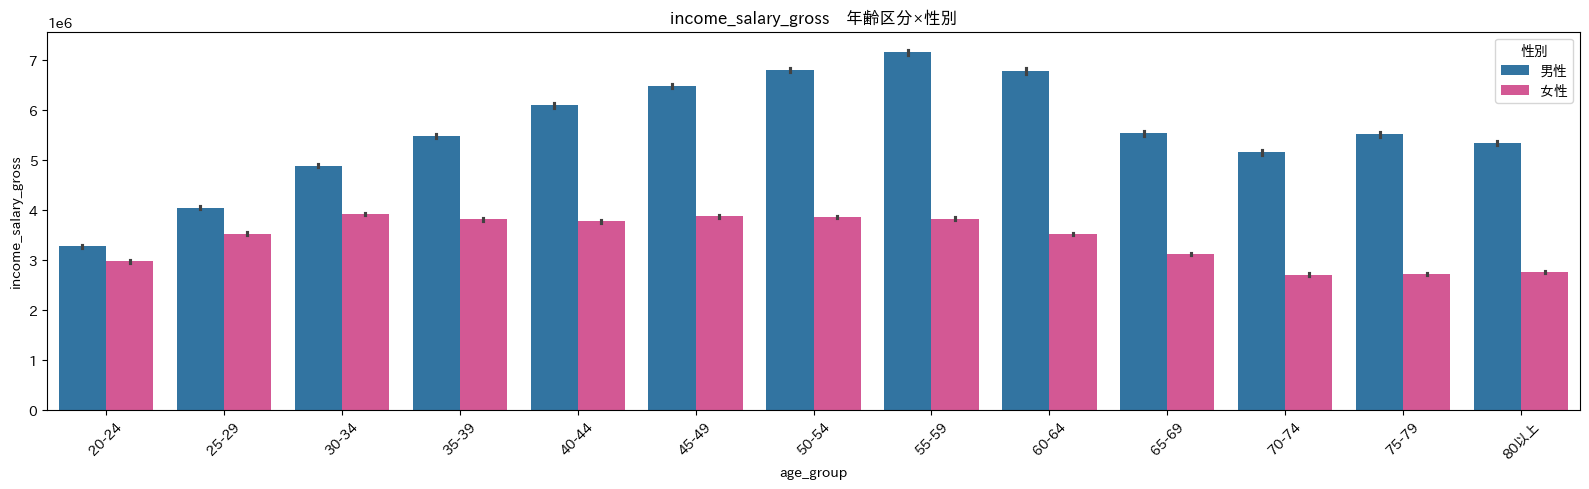

  → 04_datacheck\fig4_income_pension_gross_年齢区分×性別_barplot.png


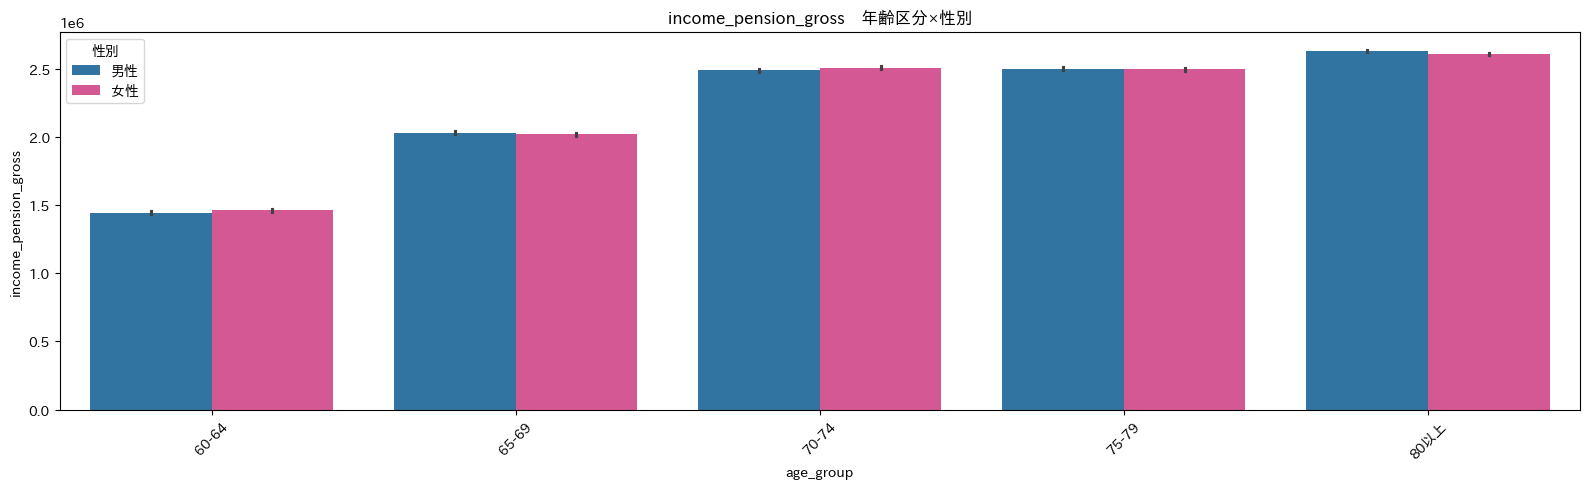

  → 04_datacheck\fig4_tax_amount_年齢区分×性別_barplot.png


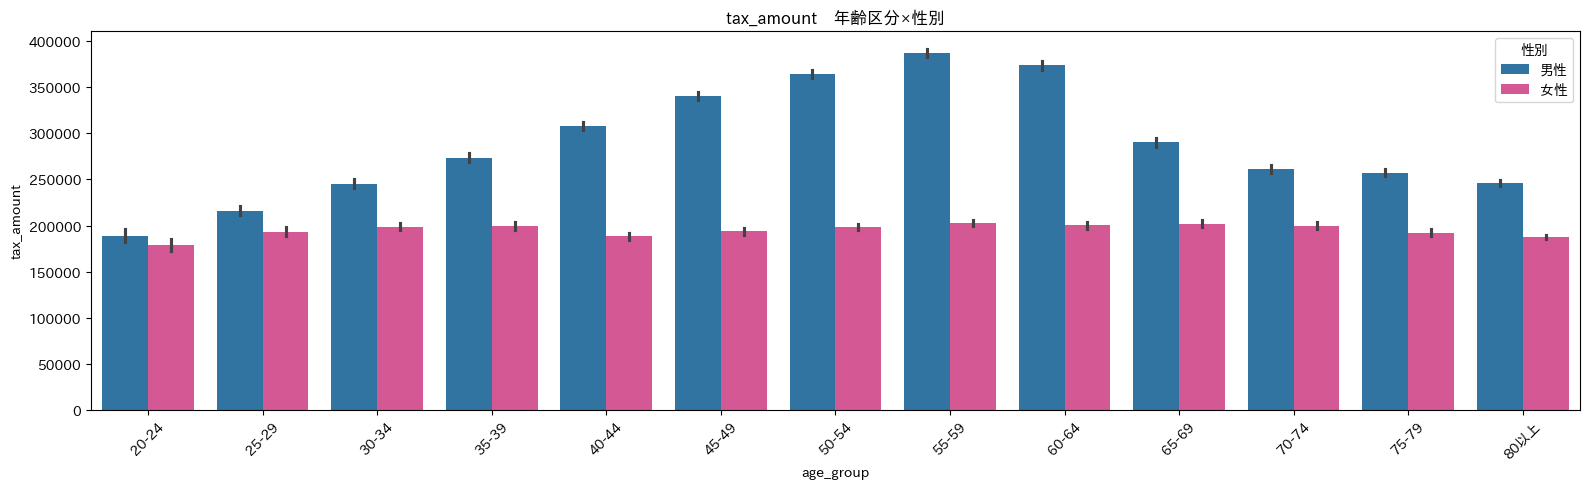

In [12]:
## 給与収入を年齢×性別で区分
barplot_by_category(df, "income_salary_gross", "both", show=True)
## 年金収入を年齢×性別で区分
barplot_by_category(df, "income_pension_gross", "both", show=True)
## 税額を年齢×性別で区分
barplot_by_category(df, "tax_amount", "both", show=True)

---


# fig5 : heatmap

In [13]:
def plot_heatmap(df, figsize=(16, 8), cmap='coolwarm', annot=True, show: bool = False):
    """
    df      : データフレーム
    figsize : グラフサイズ（デフォルト(16,8)）
    cmap    : カラーマップ（デフォルト'coolwarm'）
    annot   : 相関係数を表示するか（デフォルトTrue）
    """
    df_corr = df.drop(df.select_dtypes(include='object').columns, axis=1).corr()

    plt.figure(figsize=figsize)
    sns.heatmap(
        df_corr,
        annot=annot,
        cmap=cmap,
        center=0
    )
    plt.title("相関係数ヒートマップ")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig5_heatmap.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig5_heatmap.png


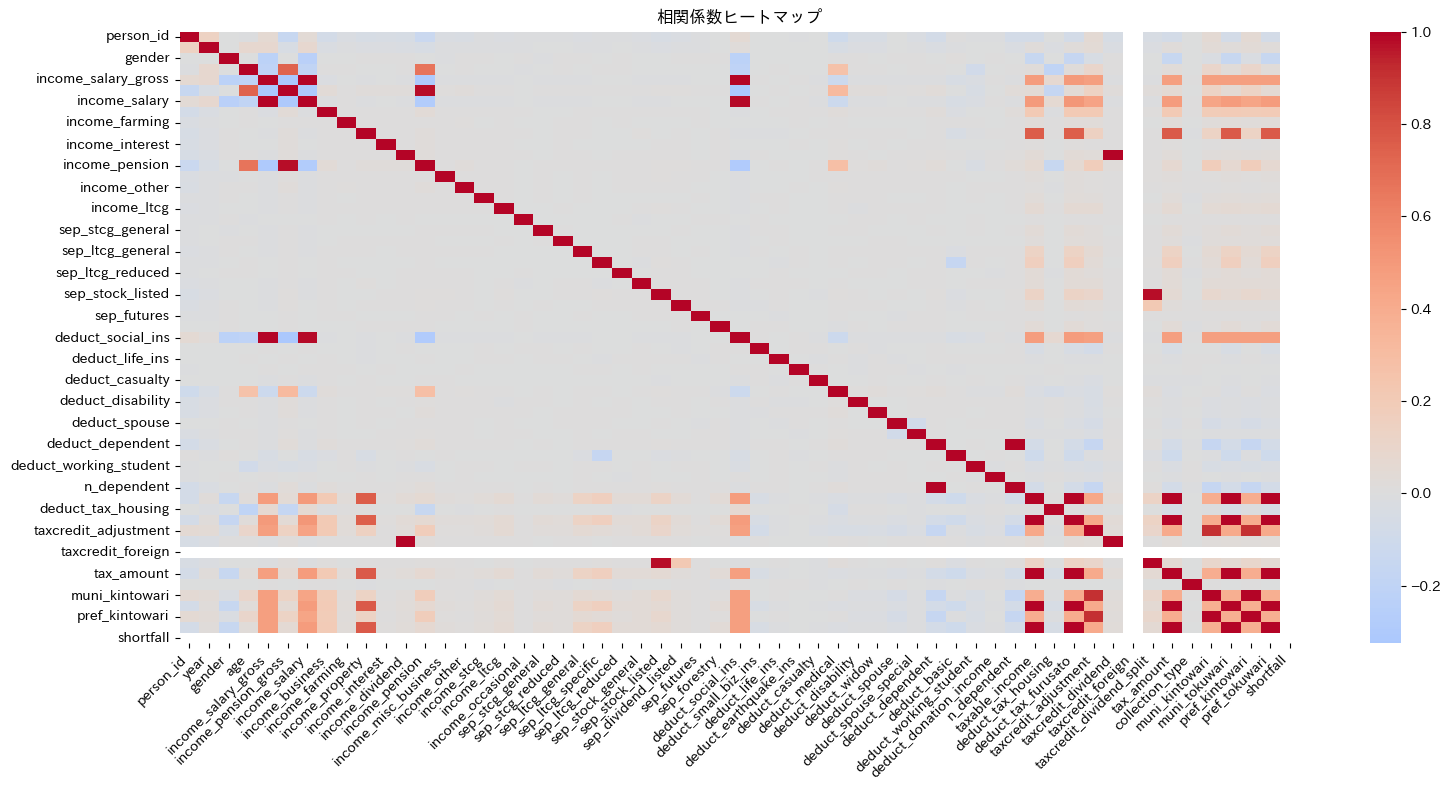

In [14]:
plot_heatmap(df, annot=False, show=True) # 相関係数の数値を非表示

---


# fig5-2 heatmap_TopBottom10

In [15]:
def plot_heatmap_TopBottom10(df, figsize=(10, 10), cmap='coolwarm', annot=True, show: bool = False):

    corr = df.corr(numeric_only=True)["tax_amount"].sort_values(ascending=False).drop(["tax_amount","person_id", "year"])
    corr_top_bottom = pd.concat([corr.head(10), corr.tail(10)])

    plt.figure(figsize=figsize)
    sns.heatmap(corr_top_bottom.to_frame(), annot=annot, fmt=".2f", cmap=cmap,
                center=0, linewidths=0.5, cbar=False)
    plt.title("Feature Correlation with Target:Top10 & Bottom10", fontsize=10, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig5_heatmap_Top10andBottom10.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig5_heatmap_Top10andBottom10.png


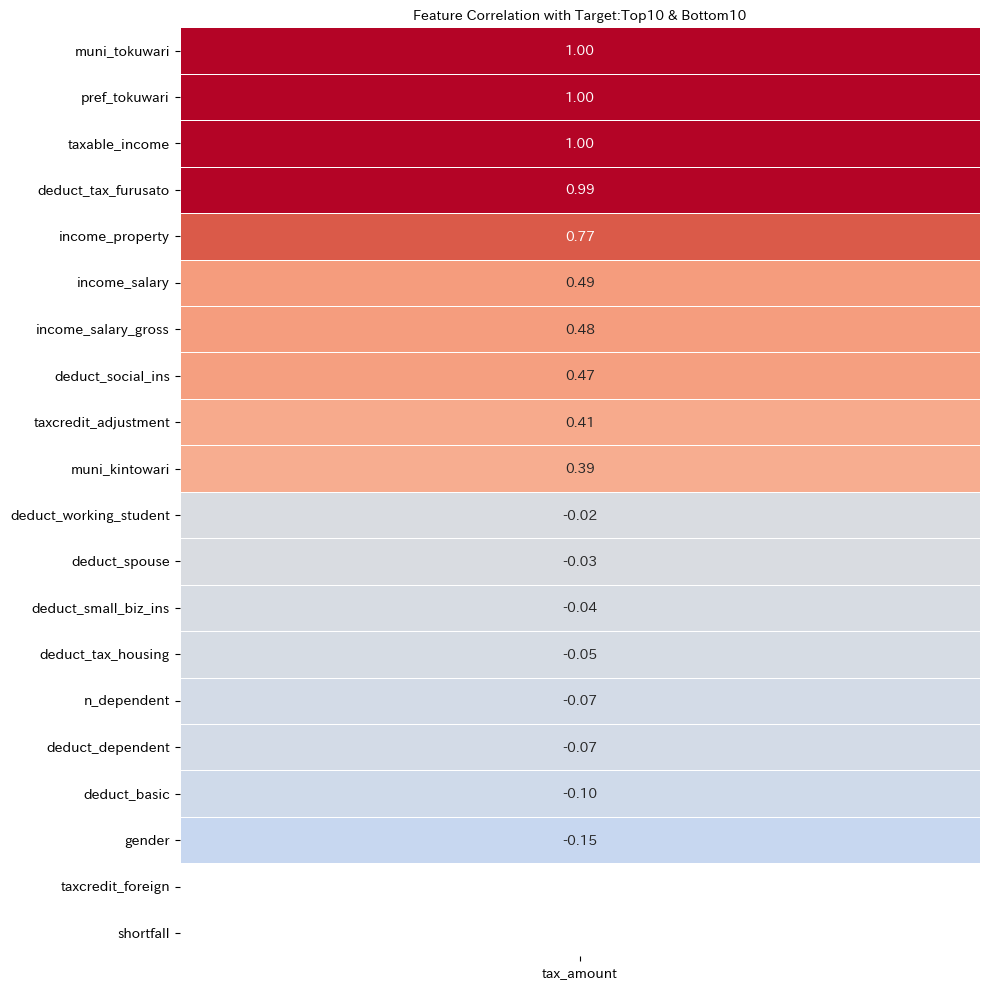

In [16]:
plot_heatmap_TopBottom10(df, show=True)

---


# fig6 : 散布図
- 給与 × 税額　---性別毎に色分
- 年金 × 税額　---性別毎に色分

In [17]:
def plot_scatter_by_year(df, x_col, y_col, show: bool = False):
    """
    x_col : x軸にしたい列名（例："給与収入"）
    y_col : y軸にしたい列名（例："税額"）
    """

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["year"] == year) & (df[x_col] > 0) & (df[y_col] > 0)]

        for gender, color in GENDER_COLORS.items():
            label = GENDER_LABELS[gender]
            df_gender = df_year[df_year["gender"] == gender]
            axes[i].scatter(
                df_gender[x_col],
                df_gender[y_col],
                alpha=0.5,
                c=color,
                label=label
            )

        axes[i].set_title(f"{year}年度")
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel(y_col)
        axes[i].legend(title="性別",loc="upper left")
    fig.suptitle(f"年度　{x_col} vs {y_col}")
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig6_scatter_{x_col}and{y_col}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig6_scatter_income_salary_grossandtax_amount.png


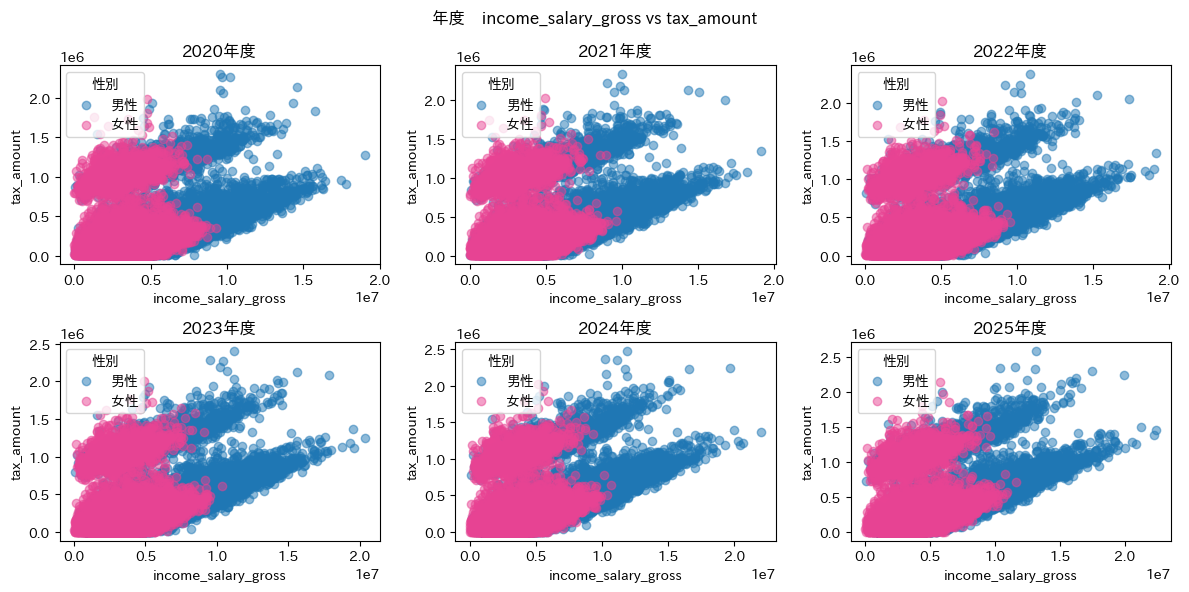

  → 04_datacheck\fig6_scatter_income_pension_grossandtax_amount.png


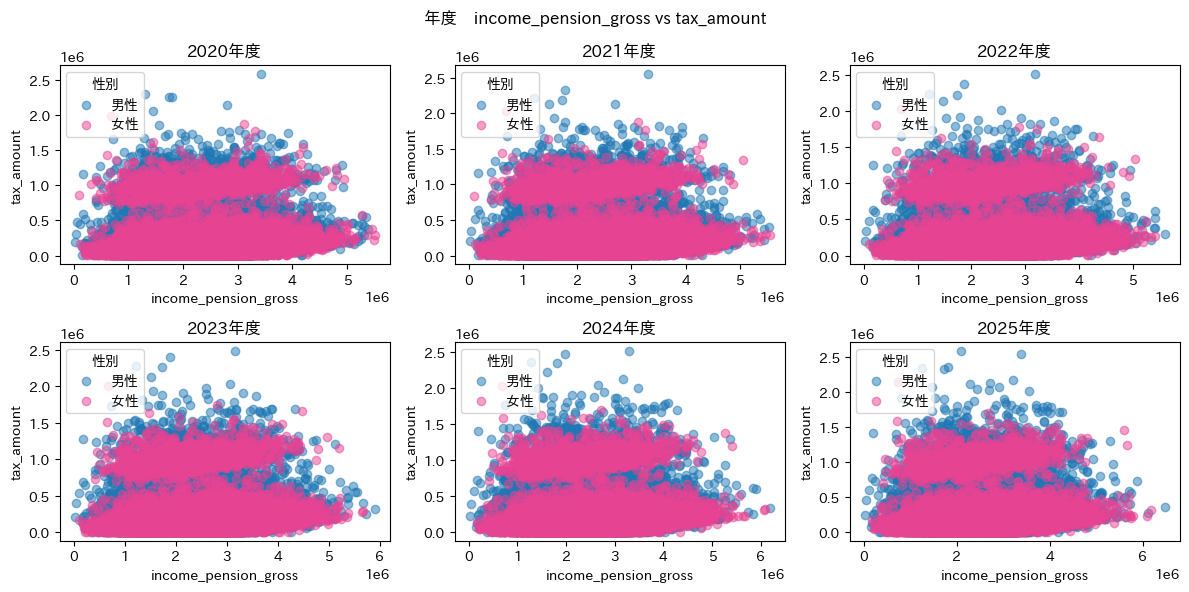

In [18]:
## 給与収入と税額の散布図
plot_scatter_by_year(df, "income_salary_gross", "tax_amount", show=True)
## 年金収入と税額の散布図
plot_scatter_by_year(df, "income_pension_gross", "tax_amount", show=True)

---


# fig7 税額控除散布図（所得税率ごとに色分）
- 給与 × ふるさと納税寄付金控除額
- 給与 × 住宅借入金等特別控除額

In [19]:
# 所得税率区分（tax_reform.compute_income_tax_rateのブラケットに対応するラベル）
_TAX_RATE_LABELS = {
    0.05105: "5%",
    0.10210: "10%",
    0.20420: "20%",
    0.23483: "23%",
    0.33693: "33%",
    0.40840: "40%",
    0.45945: "45%",
}
_TAX_BRACKET_ORDER = ["5%", "10%", "20%", "23%", "33%", "40%", "45%"]

def _income_tax_bracket_label(taxable_income):
    """taxable_income から compute_income_tax_rate のブラケットに対応するラベル（"5%"〜"45%"）を返す。"""
    rate = compute_income_tax_rate(np.asarray(taxable_income, dtype=float))
    return np.array([_TAX_RATE_LABELS.get(round(r, 5), "?") for r in rate])


def plot_scatter_by_tax_bracket(df, x_col, y_col, show: bool = False):
    """
    x_col : x軸にしたい列名（例："income_salary_gross"）
    y_col : y軸にしたい列名（例："deduct_tax_furusato"）
    taxable_income から算出した所得税率区分（5%〜45%）で色分けし、年度別に表示する。
    """
    years  = sorted(df["year"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(_TAX_BRACKET_ORDER)))

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["year"] == year) & (df[x_col] > 0) & (df[y_col] > 0)].copy()
        df_year["tax_bracket"] = _income_tax_bracket_label(df_year["taxable_income"])

        for bracket, color in zip(_TAX_BRACKET_ORDER, colors):
            df_b = df_year[df_year["tax_bracket"] == bracket]
            if df_b.empty:
                continue
            axes[i].scatter(
                df_b[x_col], df_b[y_col],
                alpha=0.3, s=6, c=[color],
                label=bracket if i == 0 else None
            )

        axes[i].set_title(f"{year}年度", fontsize=9)
        axes[i].set_xlabel(x_col, fontsize=8)
        axes[i].set_ylabel(y_col, fontsize=8)

    fig.suptitle(f"{x_col} vs {y_col}（所得税率区分別）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="所得税率区分", loc="upper right", fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    path = os.path.join(SAVE_DIR, f"fig7_scatter_{x_col}and{y_col}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig7_scatter_income_salary_grossanddeduct_tax_furusato.png


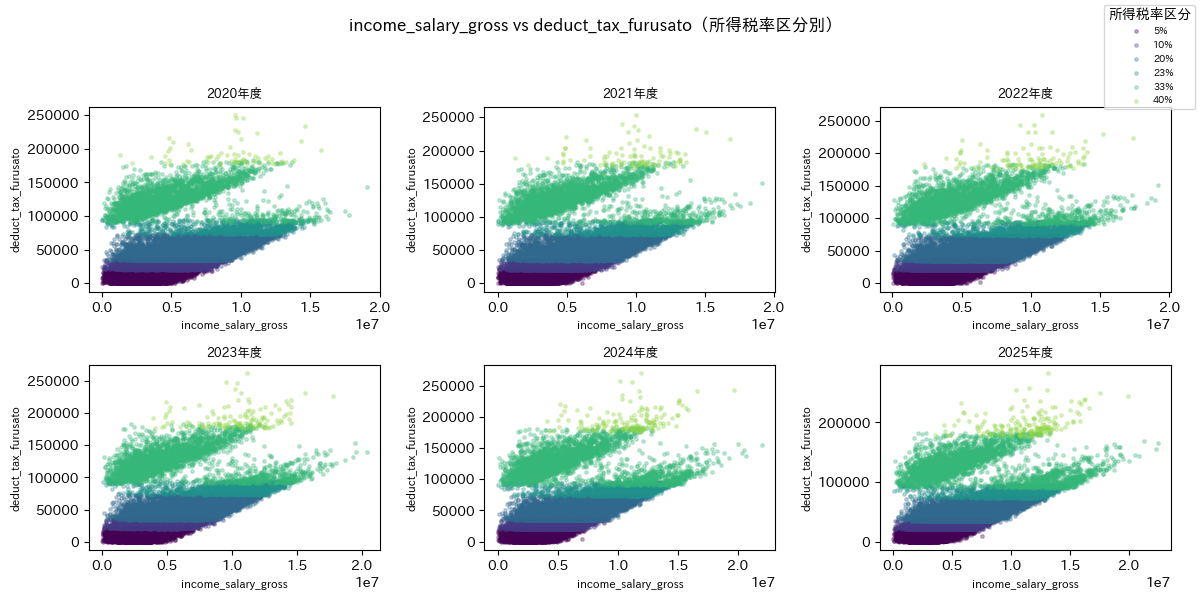

  → 04_datacheck\fig7_scatter_income_salary_grossanddeduct_tax_housing.png


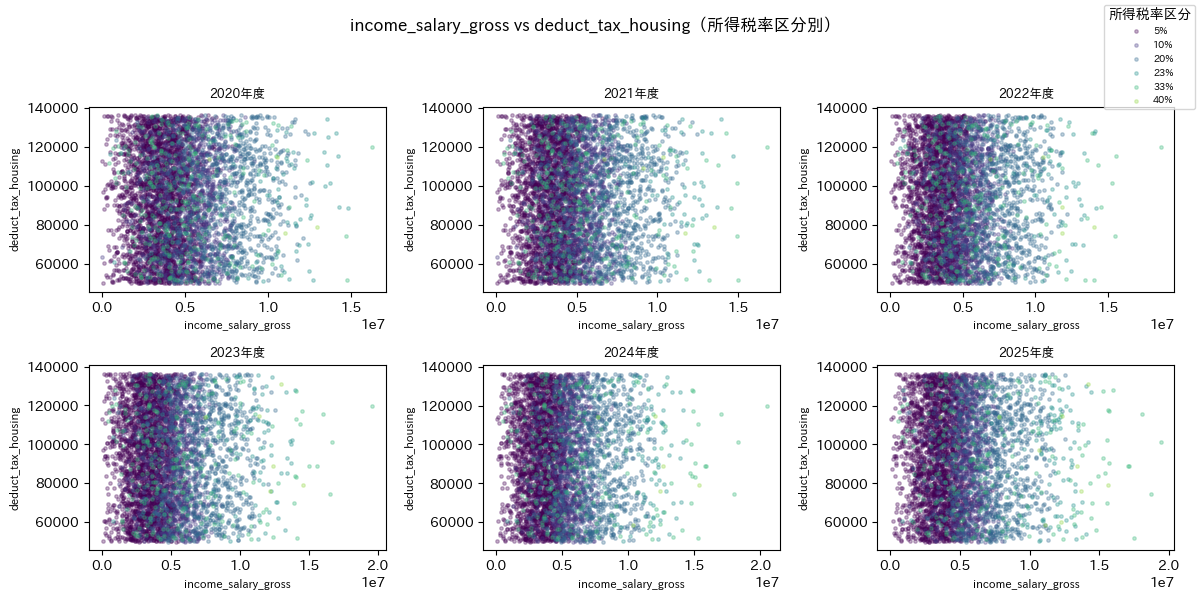

  → 04_datacheck\fig7_scatter_taxable_incomeanddeduct_tax_furusato.png


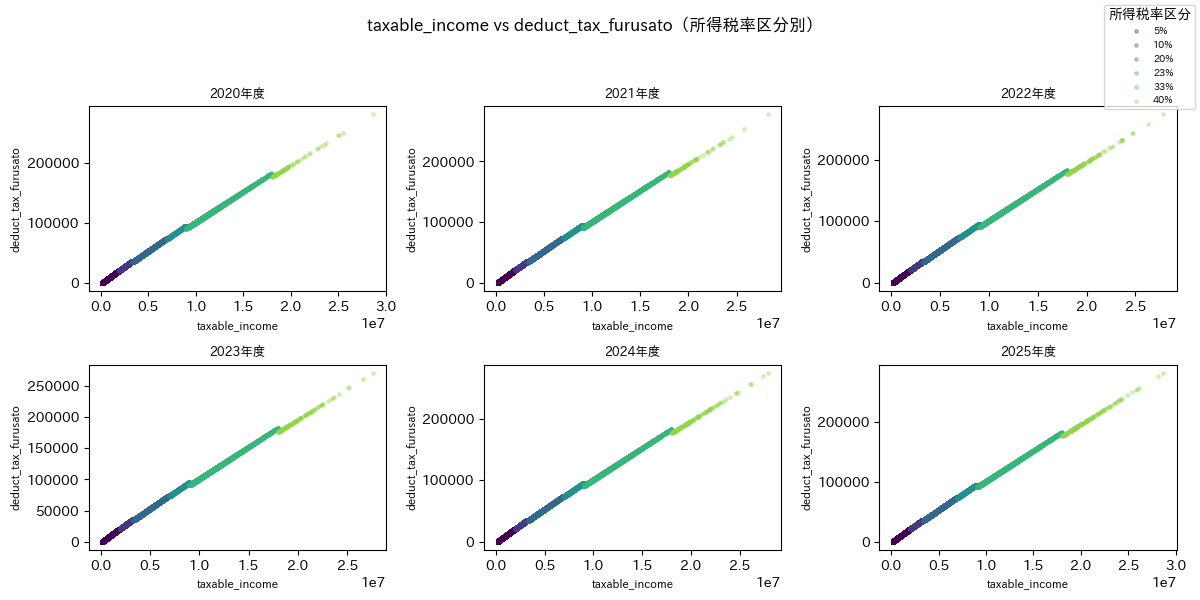

  → 04_datacheck\fig7_scatter_taxable_incomeanddeduct_tax_housing.png


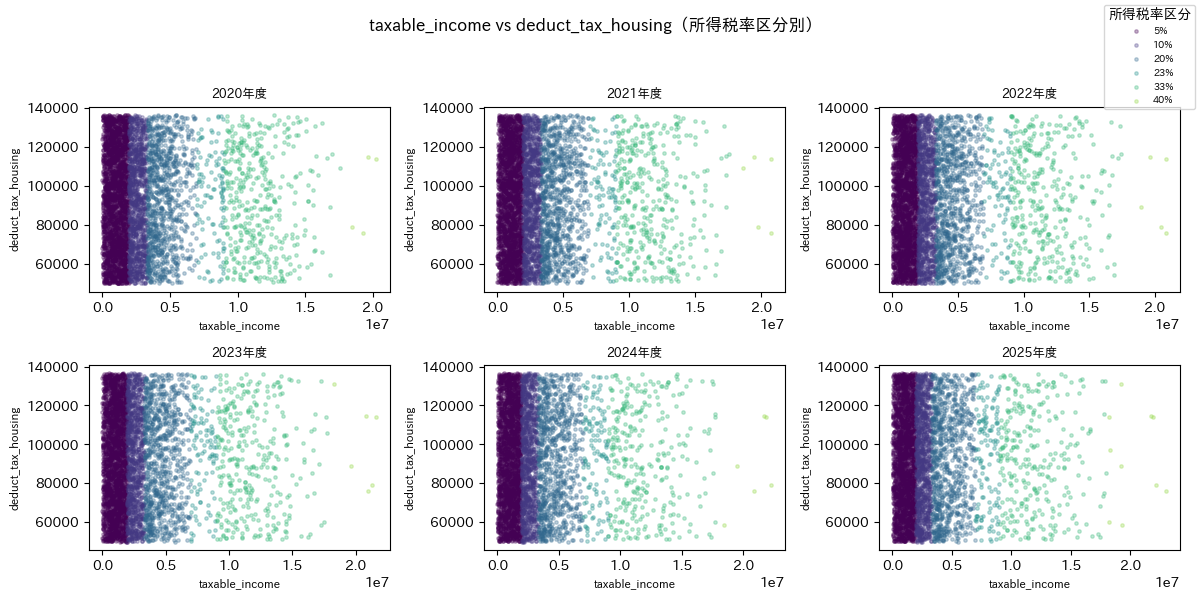

In [20]:
## 給与収入とふるさと納税控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "income_salary_gross", "deduct_tax_furusato", show=True)
## 給与収入と住宅借入金特別控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "income_salary_gross", "deduct_tax_housing", show=True)
## 税額とふるさと納税控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "taxable_income", "deduct_tax_furusato", show=True)
## 税額と住宅借入金特別控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "taxable_income", "deduct_tax_housing", show=True)

---


# fig8 定額減税影響可視化
実データでは「定額減税控除額」「tax_amount（減税額足す前）」をそのまま抽出できる想定。
tax_amount（現状値）= tax_amount（減税額足す前）+ 定額減税控除額 という関係。
ダミーデータには当該列がないため、住民税の定額減税ルール（本人1万円＋扶養親族等1人につき1万円、2024年度）で仮の値をモック生成する。

In [21]:
def mock_teigaku_reduction(df, reduction_years=(2024,2025), amount_per_person=10_000):
    """
    year が reduction_years に含まれ、tax_amount > 0 の人に定額減税控除額を仮設定し、
    以下2列を追加する（実データ投入後はこの関数は不要になる想定）。
      teigaku_reduction           : 定額減税控除額（仮）
      tax_amount_before_reduction : tax_amount（減税額足す前）（仮）
    """
    df = df.copy()
    target = df["year"].isin(reduction_years) & (df["tax_amount"] > 0)

    reduction = pd.Series(0, index=df.index)
    reduction.loc[target] = amount_per_person * (1 + df.loc[target, "n_dependent"])
    reduction = np.minimum(reduction, df["tax_amount"])  # 減税額が税額を超えないようクリップ

    df["teigaku_reduction"] = reduction
    df["tax_amount_before_reduction"] = df["tax_amount"] - reduction
    return df

In [22]:
df_mock_teigaku = mock_teigaku_reduction(df)

In [23]:
## 税額合計（億円）を年度別に積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_by_year(df, before_col="tax_amount_before_reduction",
                                    reduction_col="teigaku_reduction",
                                    show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    年度別の税額合計（億円）を、減税額足す前のtax_amountを下・定額減税控除額を上に
    積み上げて表示する（積み上げた合計が現状のtax_amountに一致する）。
    """
    yearly = df.groupby("year")[[before_col, reduction_col]].sum() / 1e8
    years = yearly.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(years, yearly[before_col], label="tax_amount（減税額足す前）", color="#1f77b4")
    ax.bar(years, yearly[reduction_col], bottom=yearly[before_col],
           label="定額減税控除額", color="#e84393")

    for yr in years:
        total = yearly.loc[yr, before_col] + yearly.loc[yr, reduction_col]
        ax.text(yr, total, f"{total:.1f}億円", ha="center", va="bottom")

    ax.set_xlabel("年度")
    ax.set_ylabel("税額合計（億円）")
    ax.set_title("定額減税の影響（年度別税額推移）")
    ax.set_xticks(years)
    ax.legend()
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig8_1_teigaku_show.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 税収総額のうち、定額減税による減額分の影響を可視化

  → 04_datacheck\fig8_1_teigaku_show.png


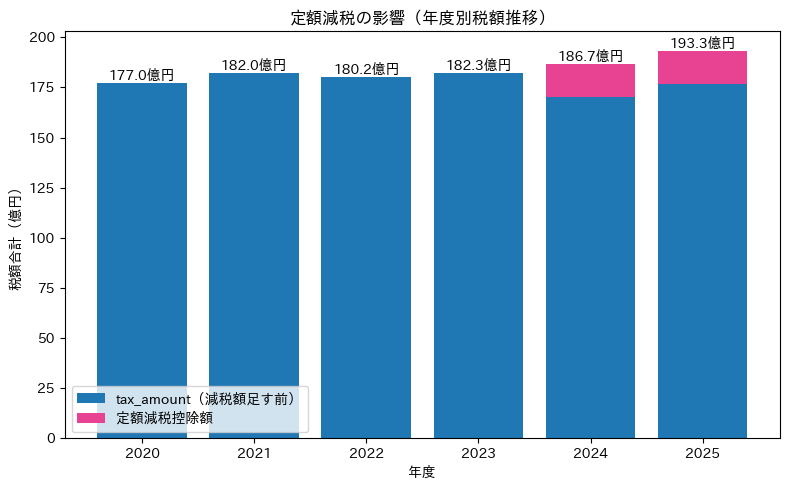

In [24]:
## 年度別の税額合計（億円）を積み上げ棒グラフで表示
plot_teigaku_reduction_by_year(df_mock_teigaku, show=True)

In [25]:
## 税額合計（億円）を年度別 / 年齢区分×性別で積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_by_age_gender(df, before_col="tax_amount_before_reduction",
                                          reduction_col="teigaku_reduction", agg="sum",
                                          show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    agg           : "sum"（合計） or "mean"（平均）
    年度（6年分）× 年齢区分 × 性別で、減税額足す前のtax_amountを下・定額減税控除額を
    上に積み上げて表示する（性別は色、減税額足す前/控除額はバー内の濃淡で区別）。
    """
    years     = sorted(df["year"].unique())
    age_order = _age_order(df)
    x         = np.arange(len(age_order))
    width     = 0.35

    gender_settings = [(0, "#1f77b4", "男性"), (1, "#e84393", "女性")]

    # 6サブプロット全てで同一のy軸範囲になるよう設定
    # sharey=True を 465 に追加し、6つのサブプロットのy軸スケールを統一（最大値は6年度中の最大値に自動的に揃う）
    fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=True)
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax      = axes[i]
        df_year = df[df["year"] == year]

        for gi, (gender, color, label) in enumerate(gender_settings):
            grouped = (
                df_year[df_year["gender"] == gender]
                .groupby("age_group")[[before_col, reduction_col]]
                .agg(agg)
                .reindex(age_order)
                .fillna(0)
            )
            offset = (gi - 0.5) * width
            ax.bar(x + offset, grouped[before_col], width, color=color, alpha=0.9,
                   label=f"{label}（減税前）" if i == 0 else None)
            ax.bar(x + offset, grouped[reduction_col], width, bottom=grouped[before_col],
                   color=color, alpha=0.4, hatch="//",
                   label=f"{label}（定額減税）" if i == 0 else None)

        ax.set_title(f"{year}年度", fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(age_order, rotation=45, fontsize=6)
        ax.tick_params(axis="y", labelsize=7)

    label_agg = "合計" if agg == "sum" else "平均"
    fig.supylabel(f"税額{label_agg}（円）", fontsize=9)
    fig.suptitle(f"定額減税の影響（年齢区分×性別・{label_agg}）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    path = os.path.join(SAVE_DIR, f"fig8_2_teigaku_age_gender_show.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 年齢区分 × 性別ごとの税額の可視化
2024年、2025年については定額減税による減少を斜線バーで表示

  → 04_datacheck\fig8_2_teigaku_age_gender_show.png


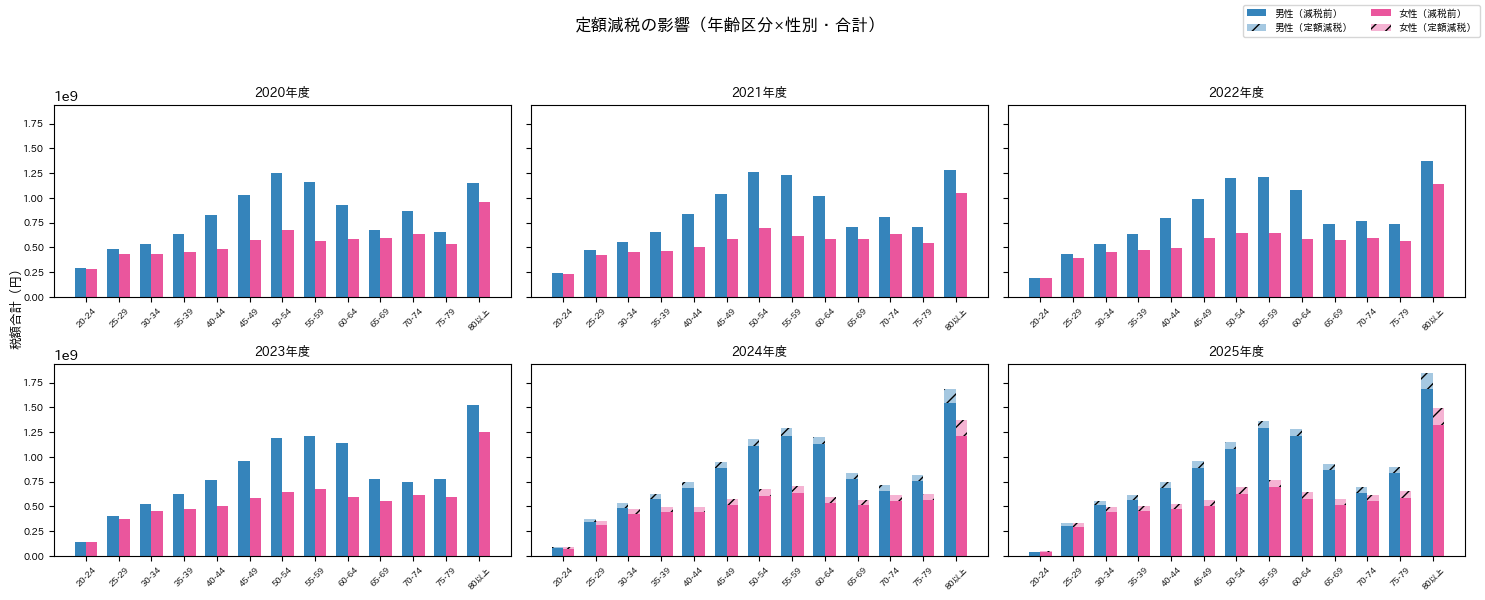

  → 04_datacheck\fig8_2_teigaku_age_gender_show.png


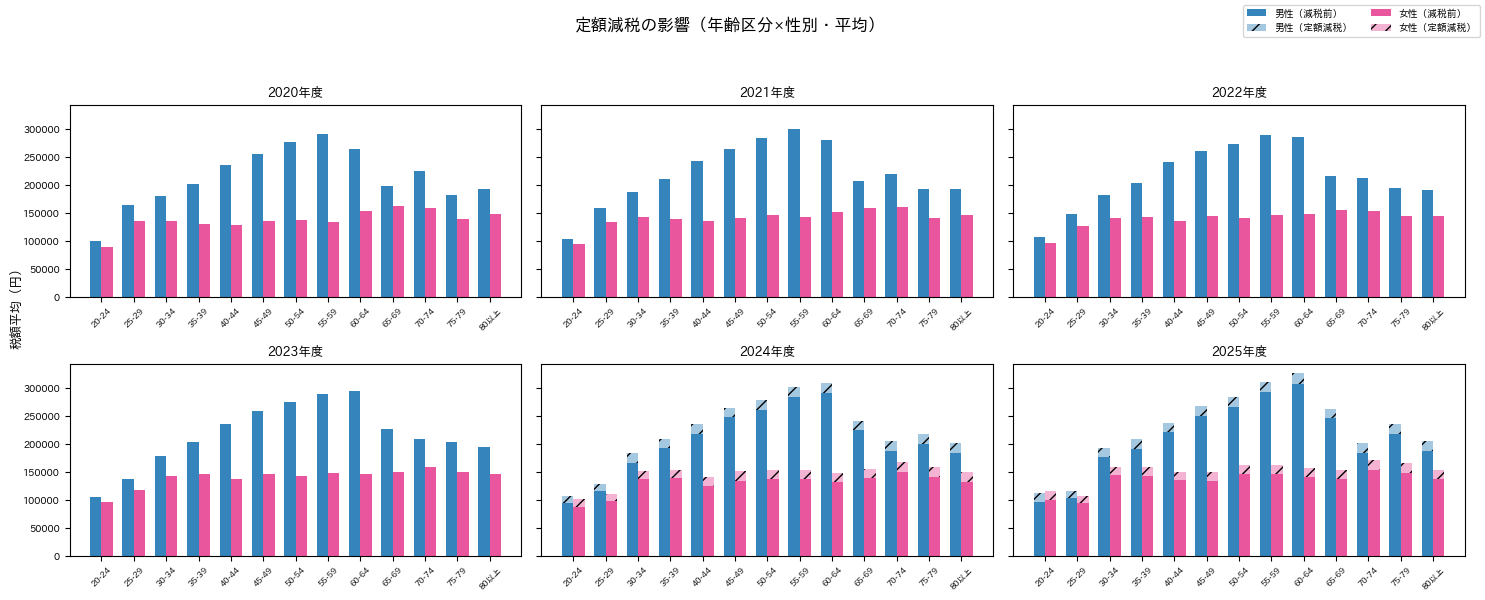

In [26]:
## 年度別の税額合計を年齢区分×性別（合計）で積み上げ棒グラフで表示
plot_teigaku_reduction_by_age_gender(df_mock_teigaku, agg="sum", show=True)
## 年度別の税額合計を年齢区分×性別（平均）で積み上げ棒グラフで表示
plot_teigaku_reduction_by_age_gender(df_mock_teigaku, agg="mean", show=True)

In [27]:
## 税額合計を年齢区分別・年度推移（合計・平均）で積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_yearly_by_age(df, before_col="tax_amount_before_reduction",
                                          reduction_col="teigaku_reduction", agg="sum",
                                          show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    agg           : "sum"（合計） or "mean"（平均）
    年齢区分ごとにサブプロットを分け（1行3つ）、各サブプロット内はx軸=年度、
    減税額足す前のtax_amountを下・定額減税控除額を上に積み上げて表示する
    （性別は色、減税額足す前/控除額はバー内の濃淡で区別）。
    """
    years     = sorted(df["year"].unique())
    age_order = _age_order(df)
    x         = np.arange(len(years))
    width     = 0.35

    gender_settings = [(0, "#1f77b4", "男性"), (1, "#e84393", "女性")]

    n_cols = 5
    n_rows = -(-len(age_order) // n_cols)  # 切り上げ（マイナスの切り捨てをマイナスで戻すことで切り上げを実現）

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows), sharey=True)
    axes = axes.flatten()

    for i, age_group in enumerate(age_order):
        ax     = axes[i]
        df_age = df[df["age_group"] == age_group]

        for gi, (gender, color, label) in enumerate(gender_settings):
            grouped = (
                df_age[df_age["gender"] == gender]
                .groupby("year")[[before_col, reduction_col]]
                .agg(agg)
                .reindex(years)
                .fillna(0)
            )
            offset = (gi - 0.5) * width
            ax.bar(x + offset, grouped[before_col], width, color=color, alpha=0.9,
                   label=f"{label}（減税前）" if i == 0 else None)
            ax.bar(x + offset, grouped[reduction_col], width, bottom=grouped[before_col],
                   color=color, alpha=0.4, hatch="//",
                   label=f"{label}（定額減税）" if i == 0 else None)

        ax.set_title(age_group, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(years, fontsize=6)
        ax.set_xlabel("year", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)

    for j in range(len(age_order), len(axes)):
        axes[j].set_visible(False)

    label_agg = "合計" if agg == "sum" else "平均"
    fig.supylabel(f"税額{label_agg}（円）", fontsize=9)
    fig.suptitle(f"定額減税の影響（年齢区分別・{label_agg}）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    path = os.path.join(SAVE_DIR, f"fig8_3_teigaku_yearsort_show.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig8_3_teigaku_yearsort_show.png


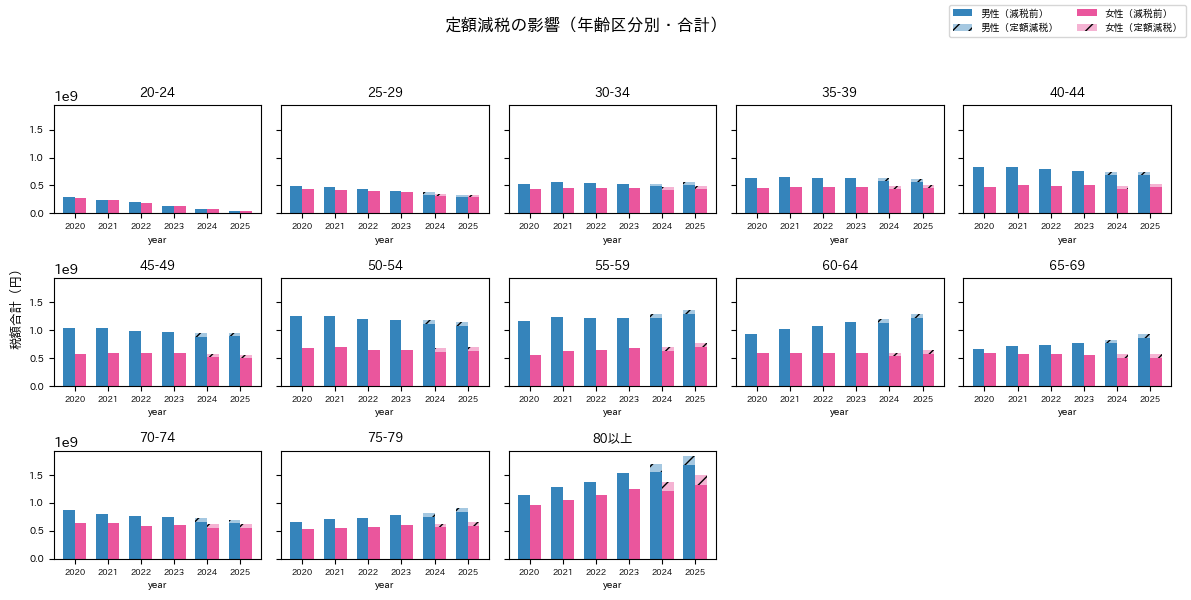

  → 04_datacheck\fig8_3_teigaku_yearsort_show.png


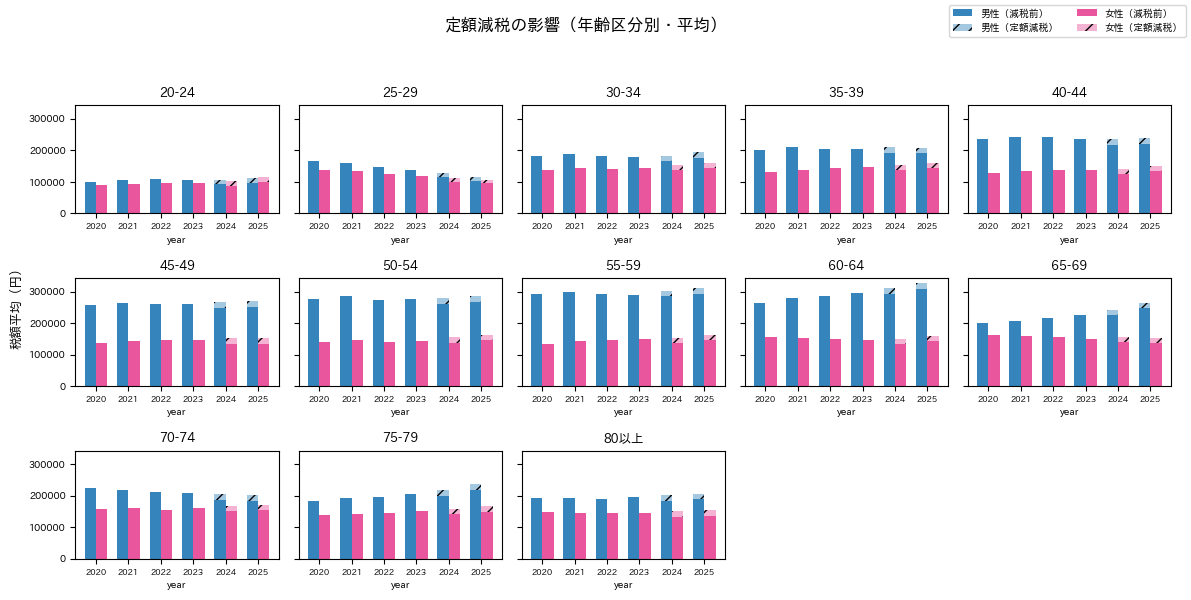

In [28]:
## 税額合計を年齢区分別・年度推移（合計）で積み上げ棒グラフで表示
plot_teigaku_reduction_yearly_by_age(df_mock_teigaku, agg="sum", show=True)
## 税額合計を年齢区分別・年度推移（平均）で積み上げ棒グラフで表示
plot_teigaku_reduction_yearly_by_age(df_mock_teigaku, agg="mean", show=True)

---


# fig9 : barplot 給与収入と給与所得の関係を可視化
税制改正による給与所得控除の増加に伴う所得減少の影響を確認する

In [29]:
def plot_salary_income_yearly(df, gross_col="income_salary_gross", net_col="income_salary",
                              show: bool = False):
    """
    gross_col : 給与収入合計の列名
    net_col   : 給与所得合計の列名
    x軸=year、給与収入と給与所得を隣り合わせのバーで表示する。
    左に合計、右に平均を並べて表示する（同一条件）。
    """
    df_long = df.melt(
        id_vars=["year"],
        value_vars=[gross_col, net_col],
        var_name="種別", value_name="金額",
    )
    df_long["種別"] = df_long["種別"].map({gross_col: "給与収入", net_col: "給与所得"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for ax, estimator, label_agg in zip(axes, [np.sum, np.mean], ["合計", "平均"]):
        sns.barplot(
            data=df_long,
            x="year", y="金額", hue="種別",
            estimator=estimator,
            ax=ax,
        )
        ax.set_title(f"給与収入・給与所得の年度推移（{label_agg}）")
        ax.set_xlabel("year")
        ax.set_ylabel(f"金額（円・{label_agg}）")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig9_給与収入vs給与所得_barplot.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig9_給与収入vs給与所得_barplot.png


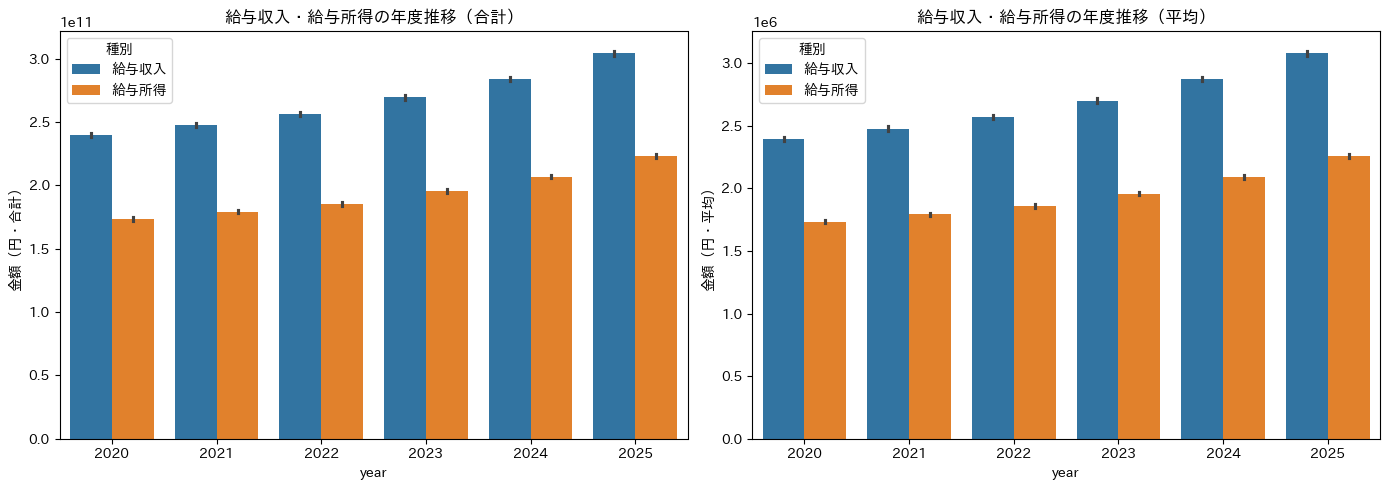

In [30]:
plot_salary_income_yearly(df_mock_teigaku, show=True)

In [31]:
print("Finished all plots")

Finished all plots
